# Лабораторная работа 1-2: Решение систем ОДУ

## Нежёсткая задача: Брюсселятор (VIII.11.1)
## Жёсткая задача: Уравнение Релея (X.9.3)

 Выполнили: Лобачев Александр, Багацкий Дмитрий; гр. Б01-304

---

## Часть I. Нежёсткая задача — Брюсселятор

### 1. Постановка задачи

Брюсселятор — модель автокаталитической химической реакции (Лефевр, Пригожин).

$$
\begin{cases}
\dot{u} = A - (B+1)u + u^2 v, \quad u(0) = 1 \\
\dot{v} = Bu - u^2 v, \quad v(0) = 1
\end{cases}
$$

$A = 1$, $B \in [1, 5]$. Стационарная точка $(A, B/A)$. Бифуркация Хопфа при $B_{cr} = 1 + A^2 = 2$.

### 2. Методы

- Явные Рунге-Кутты порядков 1–4
- Адамс-Башфорт порядков 1–3 (разгон — РК4)

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 13,
    'axes.grid': True,
    'grid.alpha': 0.3
})

In [41]:
def brusselator_factory(A, B):
    def rhs(t, y):
        u, v = y
        return np.array([A - (B+1)*u + u**2*v, B*u - u**2*v])
    return rhs

# === Явные методы Рунге-Кутты ===

def rk1_step(f, t, y, h):
    return y + h * f(t, y)

def rk2_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h, y + h * k1)
    return y + h/2 * (k1 + k2)

def rk3_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + h/2 * k1)
    k3 = f(t + h, y - h*k1 + 2*h*k2)
    return y + h/6 * (k1 + 4*k2 + k3)

def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + h/2 * k1)
    k3 = f(t + h/2, y + h/2 * k2)
    k4 = f(t + h, y + h * k3)
    return y + h/6 * (k1 + 2*k2 + 2*k3 + k4)

def solve_rk(f, y0, t_span, h, method='rk4'):
    step_funcs = {'rk1': rk1_step, 'rk2': rk2_step,
                  'rk3': rk3_step, 'rk4': rk4_step}
    step = step_funcs[method]
    t0, tf = t_span
    n = int(np.ceil((tf - t0) / h))
    ha = (tf - t0) / n
    t_arr = np.linspace(t0, tf, n + 1)
    y_arr = np.zeros((n + 1, len(y0)))
    y_arr[0] = y0.copy()
    for i in range(n):
        y_arr[i+1] = step(f, t_arr[i], y_arr[i], ha)
        if np.any(np.abs(y_arr[i+1]) > 1e15):
            y_arr[i+1:] = np.nan; break
    return t_arr, y_arr

# === Адамс-Башфорт (порядки 1-3) ===

def solve_adams_bashforth(f, y0, t_span, h, order=3):
    t0, tf = t_span
    n = int(np.ceil((tf - t0) / h))
    ha = (tf - t0) / n
    t_arr = np.linspace(t0, tf, n + 1)
    y_arr = np.zeros((n + 1, len(y0)))
    y_arr[0] = y0.copy()

    start = min(order - 1, n)
    for i in range(start):
        y_arr[i + 1] = rk4_step(f, t_arr[i], y_arr[i], ha)

    fh = [f(t_arr[i], y_arr[i]) for i in range(start + 1)]

    for i in range(start, n):
        if order == 1:
            y_new = y_arr[i] + ha * fh[i]
        elif order == 2:
            y_new = y_arr[i] + ha / 2 * (3 * fh[i] - fh[i - 1])
        elif order == 3:
            y_new = y_arr[i] + ha / 12 * (23 * fh[i] - 16 * fh[i - 1] + 5 * fh[i - 2])

        y_arr[i + 1] = y_new
        if np.any(np.abs(y_new) > 1e15):
            y_arr[i + 1:] = np.nan
            break

        fh.append(f(t_arr[i + 1], y_arr[i + 1]))

    return t_arr, y_arr

### 3. Результаты: Брюсселятор

#### 3.1 Фазовые портреты для разных B

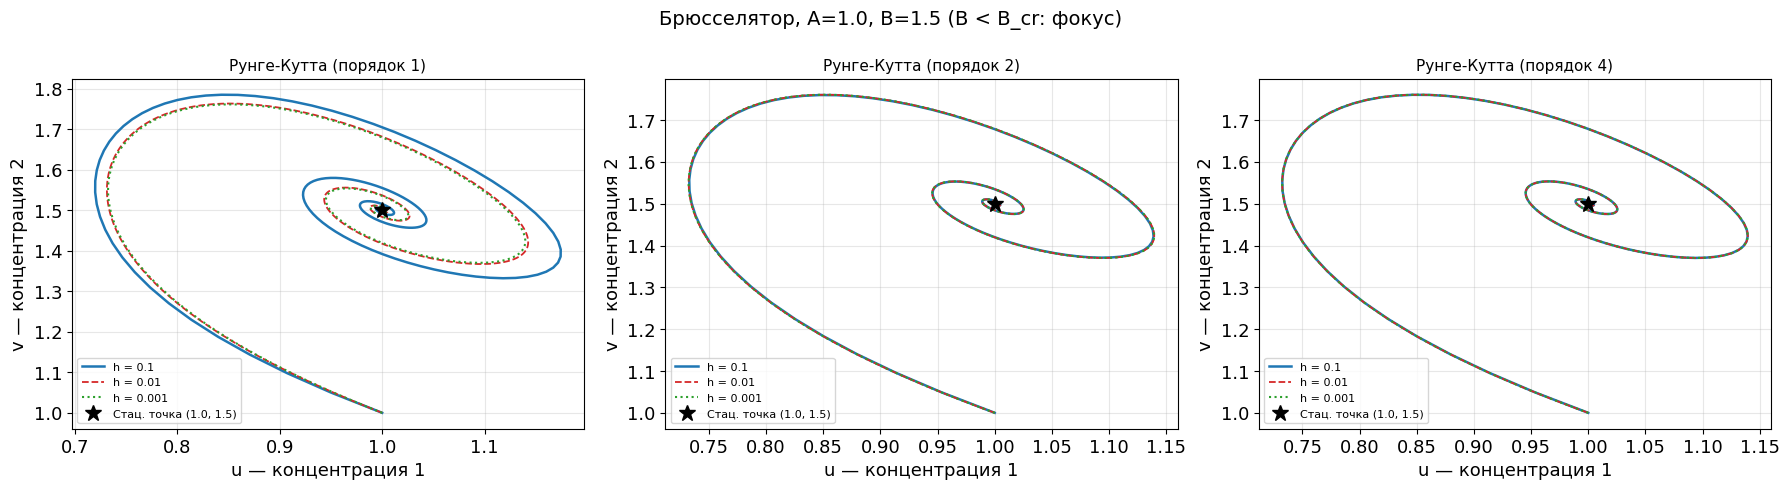

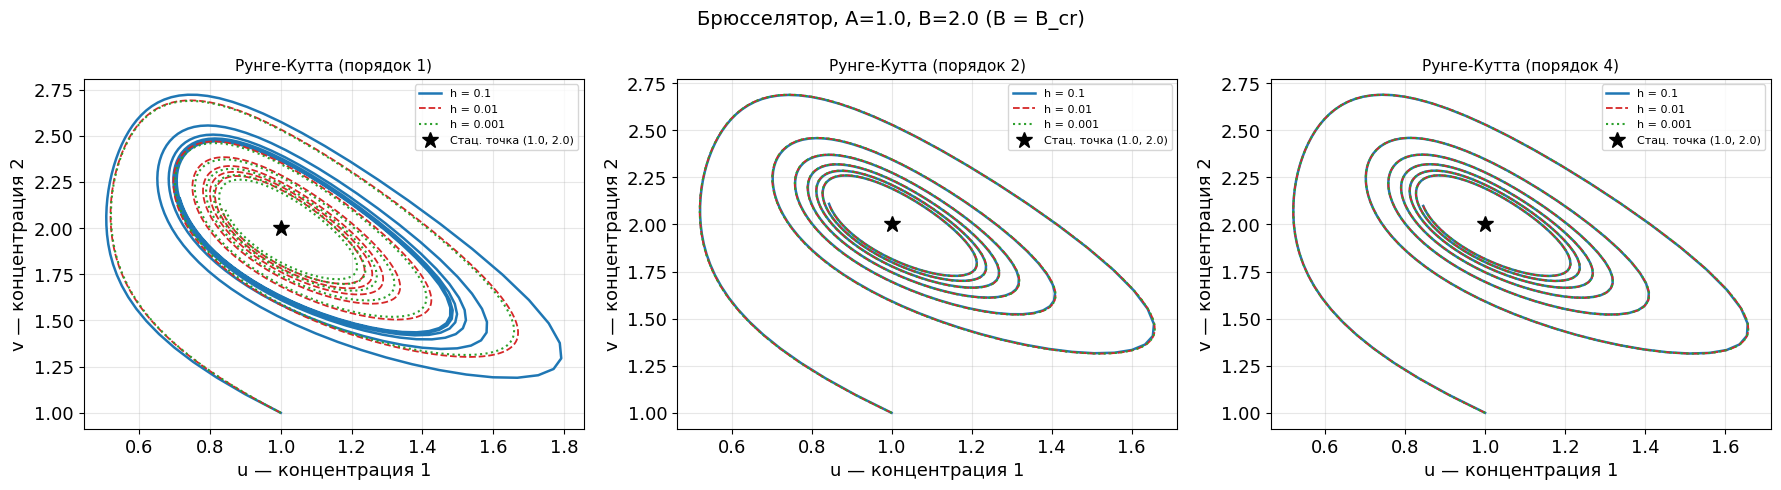

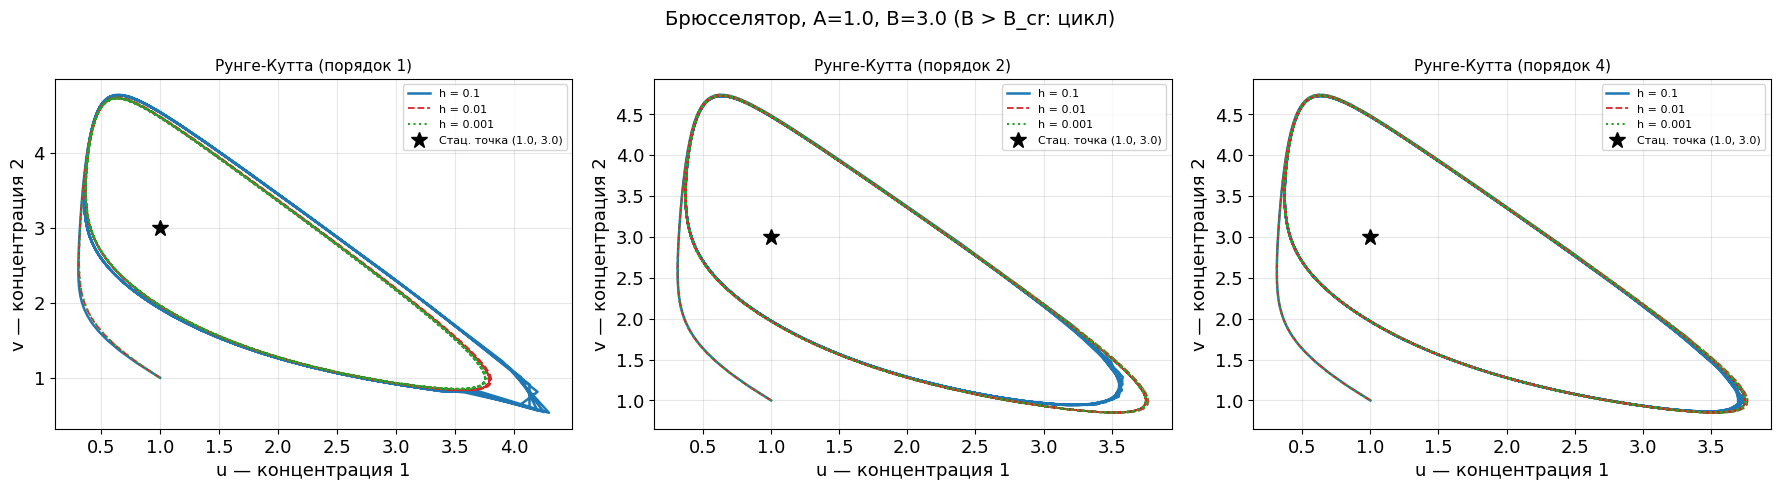

In [42]:
A = 1.0
y0_br = np.array([1.0, 1.0])
t_span_br = (0.0, 40.0)

for B in [1.5, 2.0, 3.0]:
    f_rhs = brusselator_factory(A, B)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    regime = "B < B_cr: фокус" if B < 2 else ("B = B_cr" if B == 2 else "B > B_cr: цикл")
    fig.suptitle(f'Брюсселятор, A={A}, B={B} ({regime})', fontsize=14)

    for ax, method, name in zip(axes,
            ['rk1','rk2','rk4'],
            ['Рунге-Кутта (порядок 1)','Рунге-Кутта (порядок 2)','Рунге-Кутта (порядок 4)']):
        ax.set_title(name, fontsize=11)
        ax.set_xlabel('u — концентрация 1')
        ax.set_ylabel('v — концентрация 2')

        styles = [('-', 'tab:blue', 1.8), ('--', 'tab:red', 1.3), (':', 'tab:green', 1.5)]
        for (ls, col, lw), h in zip(styles, [0.1, 0.01, 0.001]):
            t, y = solve_rk(f_rhs, y0_br, t_span_br, h, method)
            v = ~np.isnan(y[:,0])
            ax.plot(y[v,0], y[v,1], ls=ls, color=col, lw=lw, label=f'h = {h}')

        ax.plot(A, B/A, 'k*', ms=12, label=f'Стац. точка ({A}, {B/A:.1f})')
        ax.legend(fontsize=8)

    plt.tight_layout(); plt.show()

#### 3.2 Интегральные кривые u(t), v(t) — Рунге-Кутта, B = 3

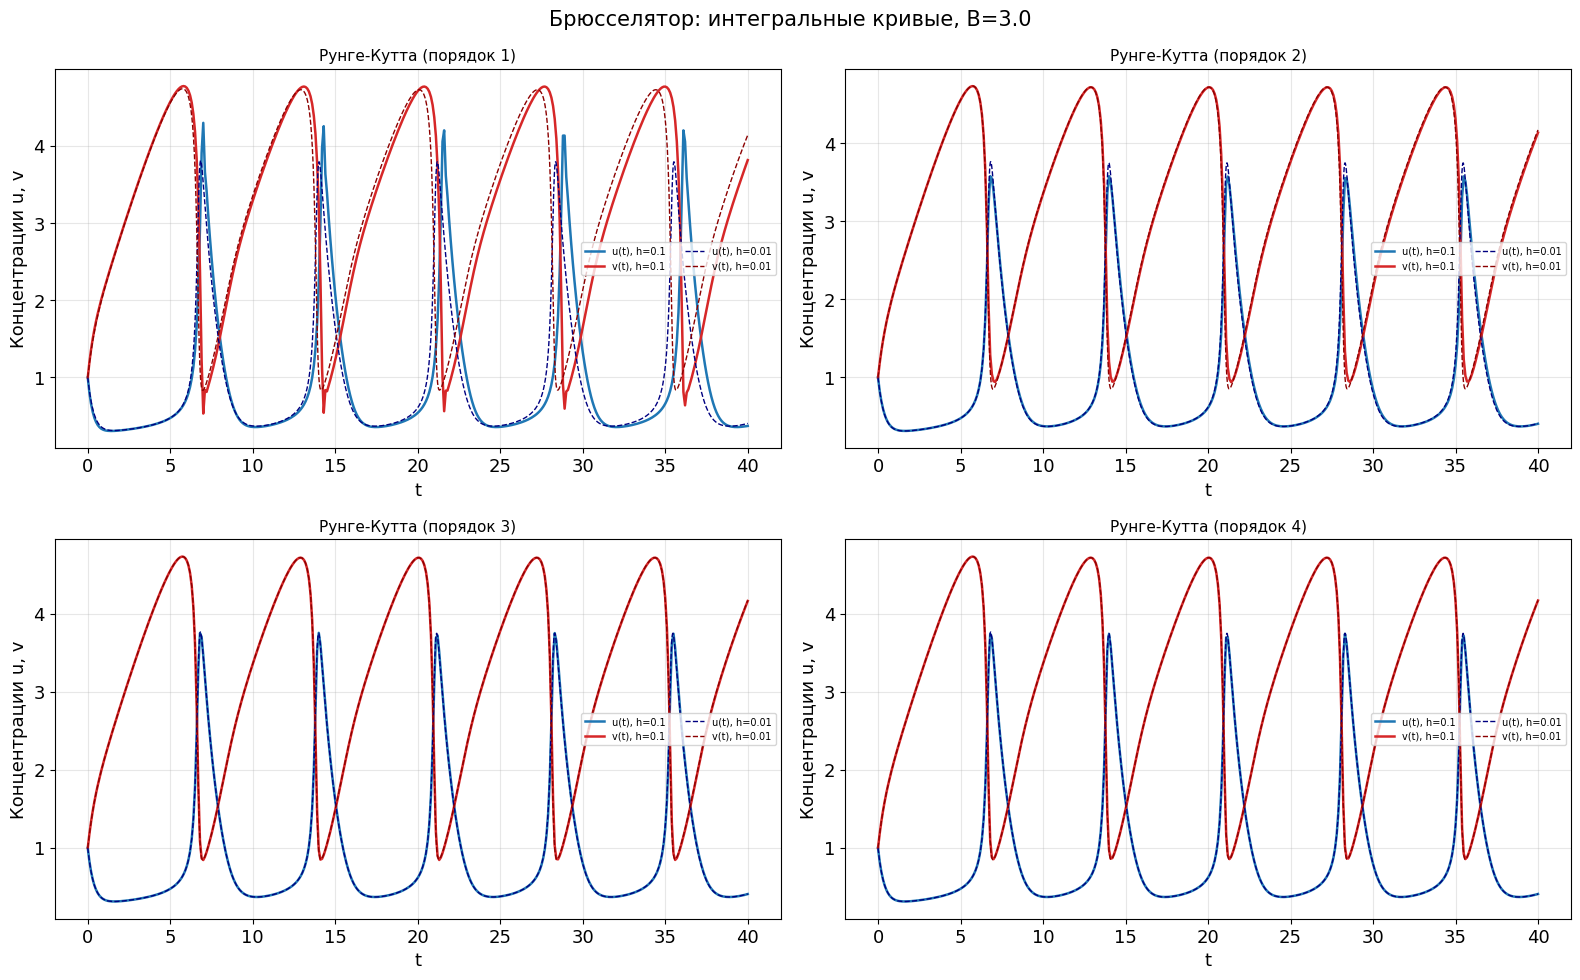

In [43]:
B = 3.0
f_rhs = brusselator_factory(A, B)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Брюсселятор: интегральные кривые, B={B}', fontsize=15)

rk_names = ['Рунге-Кутта (порядок 1)', 'Рунге-Кутта (порядок 2)',
             'Рунге-Кутта (порядок 3)', 'Рунге-Кутта (порядок 4)']

for ax, method, name in zip(axes.flat, ['rk1','rk2','rk3','rk4'], rk_names):
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('t')
    ax.set_ylabel('Концентрации u, v')

    # h = 0.1: сплошные жирные
    t, y = solve_rk(f_rhs, y0_br, t_span_br, 0.1, method)
    v = ~np.isnan(y[:,0])
    ax.plot(t[v], y[v,0], '-', color='tab:blue', lw=1.8, label='u(t), h=0.1')
    ax.plot(t[v], y[v,1], '-', color='tab:red', lw=1.8, label='v(t), h=0.1')

    # h = 0.01: штрих тонкие
    t, y = solve_rk(f_rhs, y0_br, t_span_br, 0.01, method)
    v = ~np.isnan(y[:,0])
    ax.plot(t[v], y[v,0], '--', color='navy', lw=1.0, label='u(t), h=0.01')
    ax.plot(t[v], y[v,1], '--', color='darkred', lw=1.0, label='v(t), h=0.01')

    ax.legend(fontsize=7, ncol=2)

plt.tight_layout(); plt.show()

#### 3.3 Адамс-Башфорт (порядки 1–3), B = 3

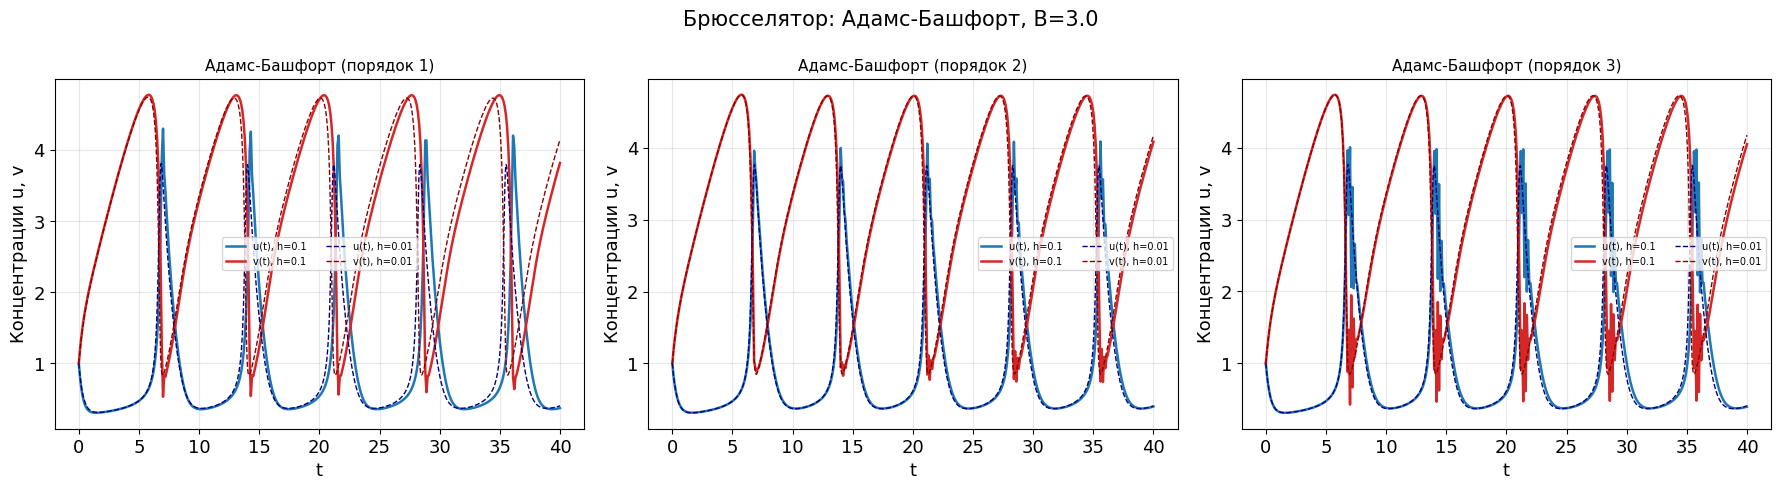

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Брюсселятор: Адамс-Башфорт, B={B}', fontsize=15)

for ax, order in zip(axes, [1, 2, 3]):
    ax.set_title(f'Адамс-Башфорт (порядок {order})', fontsize=11)
    ax.set_xlabel('t')
    ax.set_ylabel('Концентрации u, v')

    t, y = solve_adams_bashforth(f_rhs, y0_br, t_span_br, 0.1, order)
    v = ~np.isnan(y[:, 0])
    ax.plot(t[v], y[v, 0], '-', color='tab:blue', lw=1.8, label='u(t), h=0.1')
    ax.plot(t[v], y[v, 1], '-', color='tab:red', lw=1.8, label='v(t), h=0.1')

    t, y = solve_adams_bashforth(f_rhs, y0_br, t_span_br, 0.01, order)
    v = ~np.isnan(y[:, 0])
    ax.plot(t[v], y[v, 0], '--', color='navy', lw=1.0, label='u(t), h=0.01')
    ax.plot(t[v], y[v, 1], '--', color='darkred', lw=1.0, label='v(t), h=0.01')

    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

#### 3.4 Бифуркация Хопфа

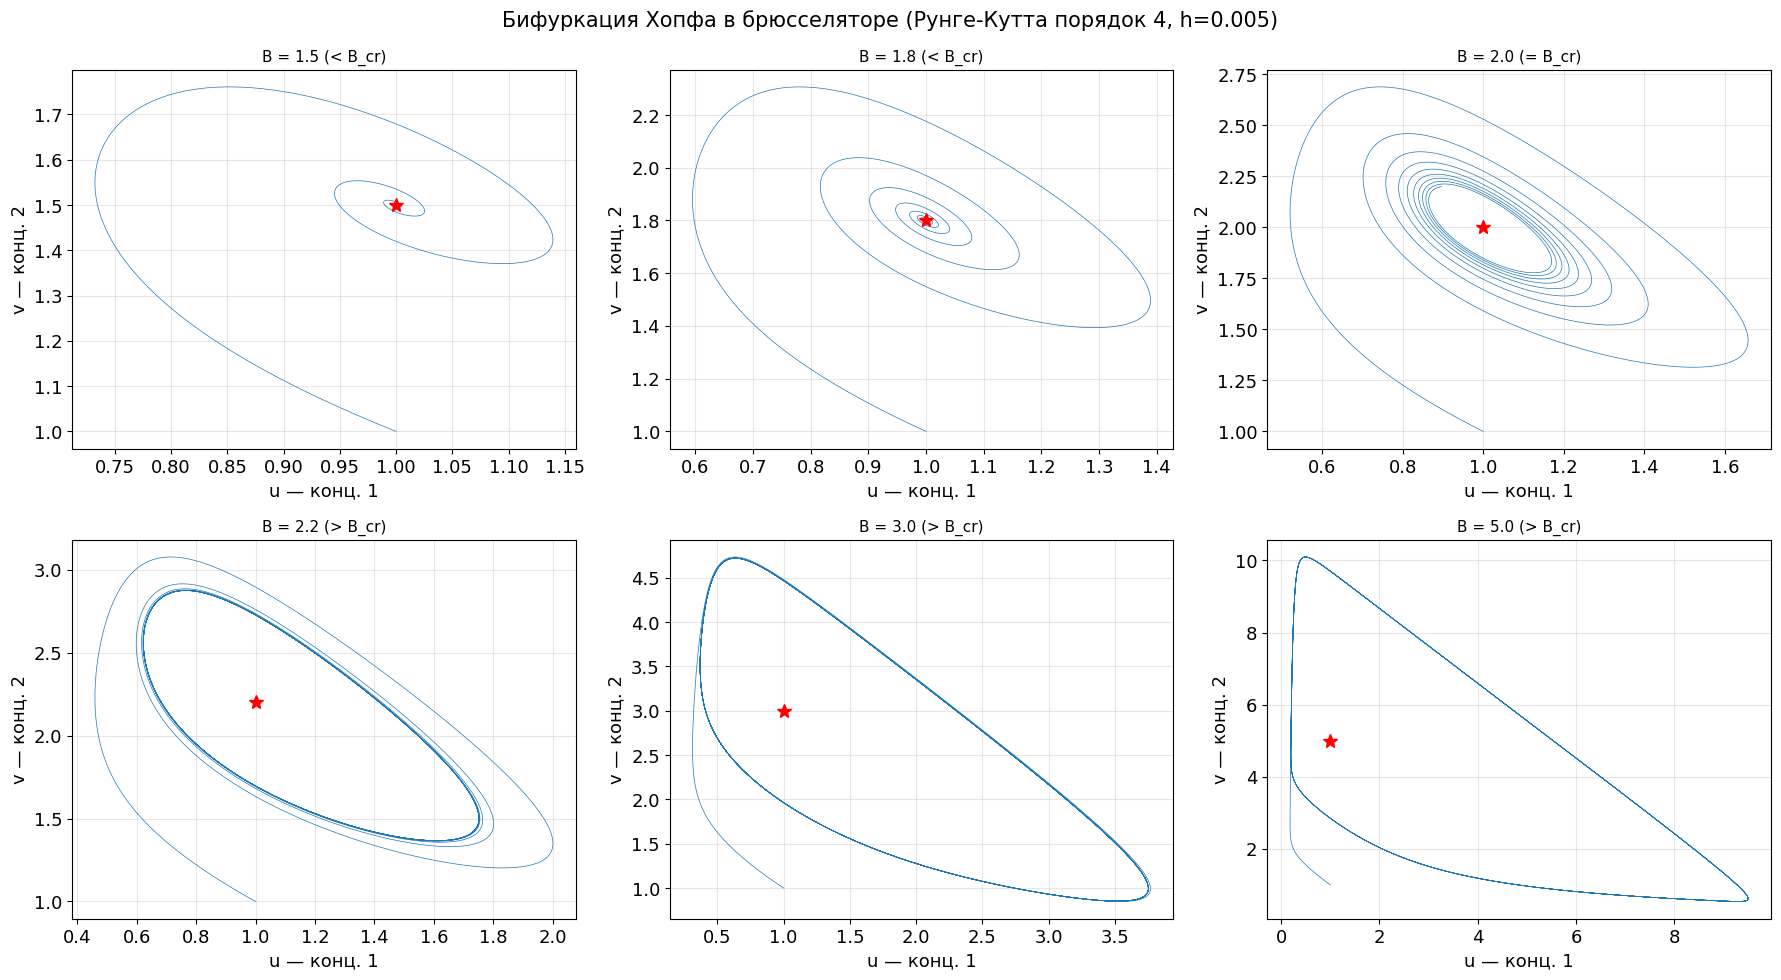

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Бифуркация Хопфа в брюсселяторе (Рунге-Кутта порядок 4, h=0.005)', fontsize=15)

for ax, B in zip(axes.flat, [1.5, 1.8, 2.0, 2.2, 3.0, 5.0]):
    t, y = solve_rk(brusselator_factory(A, B), y0_br, (0,60), 0.005, 'rk4')
    ax.plot(y[:,0], y[:,1], lw=0.5, color='tab:blue')
    ax.plot(A, B/A, 'r*', ms=10)
    r = "< B_cr" if B<2 else ("= B_cr" if B==2 else "> B_cr")
    ax.set_title(f'B = {B} ({r})', fontsize=11)
    ax.set_xlabel('u — конц. 1'); ax.set_ylabel('v — конц. 2')

plt.tight_layout(); plt.show()

#### 3.5 Сходимость

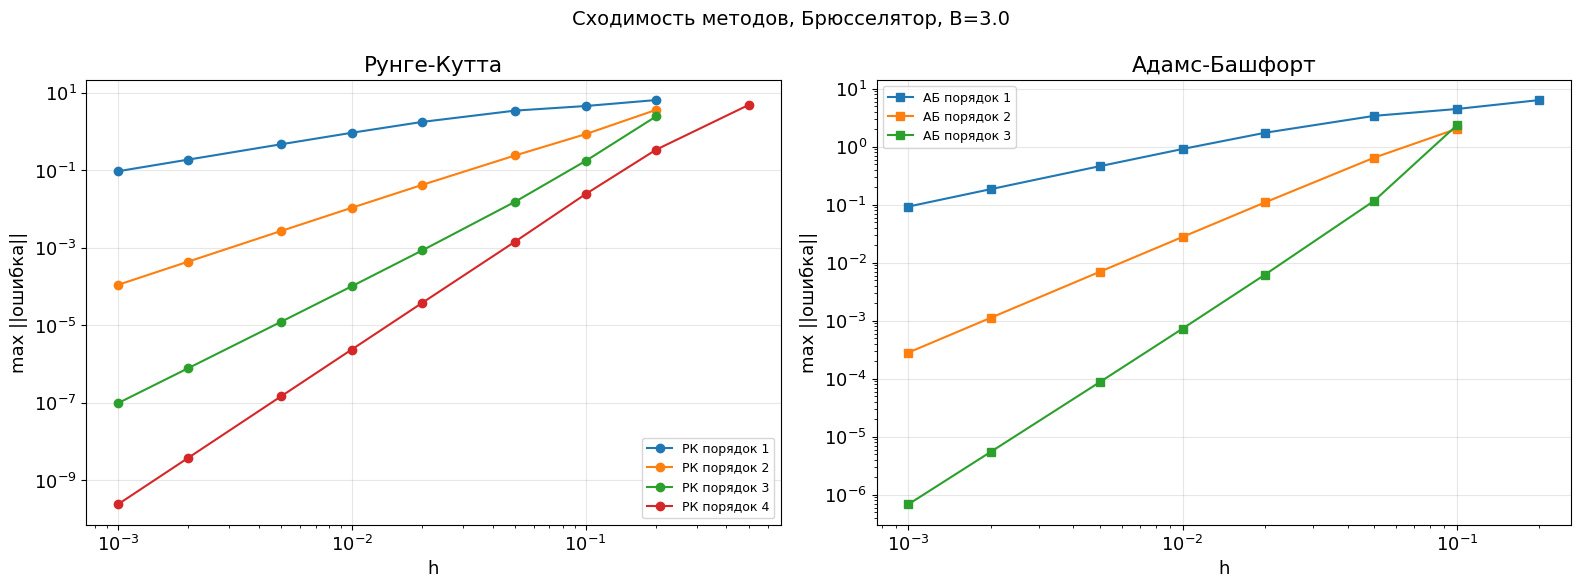

In [46]:
B = 3.0
f_rhs = brusselator_factory(A, B)
t_ref, y_ref = solve_rk(f_rhs, y0_br, t_span_br, 1e-4, 'rk4')
h_test = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Сходимость методов, Брюсселятор, B={B}', fontsize=14)

# Рунге-Кутта
ax = axes[0]
ax.set_title('Рунге-Кутта')
for method, nm in [('rk1', 'порядок 1'), ('rk2', 'порядок 2'),
                   ('rk3', 'порядок 3'), ('rk4', 'порядок 4')]:
    errs, hs = [], []
    for h in h_test:
        try:
            t, y = solve_rk(f_rhs, y0_br, t_span_br, h, method)
            if np.any(np.isnan(y)):
                continue
            yr = interp1d(t_ref, y_ref, axis=0)(t)
            e = np.max(np.linalg.norm(y - yr, axis=1))
            if np.isfinite(e) and e < 1e10:
                errs.append(e)
                hs.append(h)
        except:
            pass
    if len(errs) > 1:
        ax.loglog(hs, errs, 'o-', label=f'РК {nm}')
ax.set_xlabel('h')
ax.set_ylabel('max ||ошибка||')
ax.legend(fontsize=9)

# Адамс-Башфорт
ax = axes[1]
ax.set_title('Адамс-Башфорт')
for order in [1, 2, 3]:
    errs, hs = [], []
    for h in h_test:
        try:
            t, y = solve_adams_bashforth(f_rhs, y0_br, t_span_br, h, order)
            if np.any(np.isnan(y)):
                continue
            yr = interp1d(t_ref, y_ref, axis=0)(t)
            e = np.max(np.linalg.norm(y - yr, axis=1))
            if np.isfinite(e) and e < 1e10:
                errs.append(e)
                hs.append(h)
        except:
            pass
    if len(errs) > 1:
        ax.loglog(hs, errs, 's-', label=f'АБ порядок {order}')
ax.set_xlabel('h')
ax.set_ylabel('max ||ошибка||')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## Часть II. Жёсткая задача — Уравнение Бонгоффера–Ван-дер-Поля (X.9.5)

### 1. Постановка задачи

Рассматривается система Бонгоффера–Ван-дер-Поля, описывающая протекание тока через клеточную мембрану.

В работе используем стандартную форму:
$$
\begin{cases}
y_1' = a\left(y_1 - \dfrac{y_1^3}{3} - y_2\right), \\
y_2' = -y_1 - b y_2 + c.
\end{cases}
$$

Здесь:
- $y_1$ — **мембранный потенциал**,
- $y_2$ — **восстановительная переменная**.

### 2. Параметры задачи

По условию:
- $a = 10^3$ и $a = 10^6$,
- $y_1(0) = 2$,
- $y_2(0) = 0$,
- $T_k = 20$.

Так как в условии параметры $b$ и $c$ не зафиксированы, в работе выбираем:
- $b = 0.8$,
- $c = 0.7$.

Это стандартный набор параметров, дающий периодический режим.

### 3. Используемые методы

Для жёсткой задачи реализованы:

1. **Явный метод Эйлера**
2. **Явный метод Рунге–Кутты 4 порядка**
3. **Неявный метод Рунге–Кутты типа Радо IIA (порядок 3)**
4. **Метод Розенброка (порядок 2)**
5. **Метод Гира (порядок 2)**

### 4. Цель исследования

1. Посмотреть, как выглядит решение системы:
   - мембранный потенциал $y_1(t)$,
   - восстановительная переменная $y_2(t)$,
   - фазовый портрет.
2. Показать, что происходит с явными методами на жёсткой задаче.
3. Сравнить явные и неявные методы по:
   - устойчивости,
   - числу шагов,
   - времени расчёта,
   - ошибке относительно референсного решения.

In [62]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

In [63]:
# ============================================================
# Система Бонгоффера–Ван-дер-Поля
# ============================================================

def bonhoeffer_vdp_factory(a_fast, b, c):
    """
    y1' = a*(y1 - y1^3/3 - y2)
    y2' = -y1 - b*y2 + c
    """
    def rhs(t, y):
        y1, y2 = y
        dy1 = a_fast * (y1 - y1**3 / 3.0 - y2)
        dy2 = -y1 - b * y2 + c
        return np.array([dy1, dy2])
    return rhs

def bonhoeffer_vdp_jac_factory(a_fast, b, c):
    def jac(t, y):
        y1, y2 = y
        return np.array([
            [a_fast * (1.0 - y1**2), -a_fast],
            [-1.0, -b]
        ])
    return jac

# Основной набор параметров для отчёта
a_fast = 1e3
b = 0.8
c = 0.7

y0_bvp = np.array([2.0, 0.0])
t_span_bvp = (0.0, 20.0)

f_bvp = bonhoeffer_vdp_factory(a_fast, b, c)
jac_bvp = bonhoeffer_vdp_jac_factory(a_fast, b, c)

print("Параметры задачи:")
print(f"a = {a_fast:.0e}")
print(f"b = {b}")
print(f"c = {c}")
print(f"y1(0) = {y0_bvp[0]}  — мембранный потенциал")
print(f"y2(0) = {y0_bvp[1]}  — восстановительная переменная")
print(f"Tk = {t_span_bvp[1]}")

Параметры задачи:
a = 1e+03
b = 0.8
c = 0.7
y1(0) = 2.0  — мембранный потенциал
y2(0) = 0.0  — восстановительная переменная
Tk = 20.0


In [64]:
# ============================================================
# Вспомогательные функции
# ============================================================

def newton_solve(F, J_func, x0, tol=1e-10, max_iter=50):
    x = x0.copy()
    for _ in range(max_iter):
        Fx = F(x)
        if np.linalg.norm(Fx) < tol:
            return x
        J = J_func(x)
        dx = np.linalg.solve(J, -Fx)
        x = x + dx
        if np.linalg.norm(dx) < tol * (1 + np.linalg.norm(x)):
            return x
    return x

def max_error_to_reference(t, y, sol_dense):
    y_ref = sol_dense.sol(t).T
    return np.max(np.linalg.norm(y - y_ref, axis=1))

def safe_is_stable(y):
    if np.any(np.isnan(y)):
        return False
    if np.any(np.abs(y) > 1e10):
        return False
    return True

In [65]:
# ============================================================
# Явные методы
# ============================================================

def rk1_step(f, t, y, h):
    return y + h * f(t, y)

def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + h/2 * k1)
    k3 = f(t + h/2, y + h/2 * k2)
    k4 = f(t + h, y + h * k3)
    return y + h/6 * (k1 + 2*k2 + 2*k3 + k4)

def solve_rk(f, y0, t_span, h, method='rk4'):
    step = rk1_step if method == 'rk1' else rk4_step

    t0, tf = t_span
    n = int(np.ceil((tf - t0) / h))
    h = (tf - t0) / n

    t_arr = np.linspace(t0, tf, n + 1)
    y_arr = np.zeros((n + 1, len(y0)))
    y_arr[0] = y0.copy()

    for i in range(n):
        y_arr[i + 1] = step(f, t_arr[i], y_arr[i], h)
        if np.any(np.abs(y_arr[i + 1]) > 1e12):
            y_arr[i + 1:] = np.nan
            break

    return t_arr, y_arr

In [66]:
# ============================================================
# Неявный метод Рунге–Кутты типа Радо IIA, порядок 3
# ============================================================

def solve_radau3(f, jac, y0, t_span, h):
    # 2-stage Radau IIA, order 3
    a11, a12 = 5/12, -1/12
    a21, a22 = 3/4, 1/4
    b1, b2 = 3/4, 1/4
    c1, c2 = 1/3, 1.0

    t0, tf = t_span
    n = int(np.ceil((tf - t0) / h))
    h = (tf - t0) / n

    t_arr = np.linspace(t0, tf, n + 1)
    m = len(y0)
    y_arr = np.zeros((n + 1, m))
    y_arr[0] = y0.copy()

    I = np.eye(m)

    for i in range(n):
        tn = t_arr[i]
        yn = y_arr[i]

        z0 = np.hstack([f(tn, yn), f(tn, yn)])

        def F(z):
            k1 = z[:m]
            k2 = z[m:]

            Y1 = yn + h * (a11 * k1 + a12 * k2)
            Y2 = yn + h * (a21 * k1 + a22 * k2)

            F1 = k1 - f(tn + c1 * h, Y1)
            F2 = k2 - f(tn + c2 * h, Y2)

            return np.hstack([F1, F2])

        def JF(z):
            k1 = z[:m]
            k2 = z[m:]

            Y1 = yn + h * (a11 * k1 + a12 * k2)
            Y2 = yn + h * (a21 * k1 + a22 * k2)

            J1 = jac(tn + c1 * h, Y1)
            J2 = jac(tn + c2 * h, Y2)

            top_left = I - h * a11 * J1
            top_right = -h * a12 * J1
            bot_left = -h * a21 * J2
            bot_right = I - h * a22 * J2

            return np.block([
                [top_left, top_right],
                [bot_left, bot_right]
            ])

        z = newton_solve(F, JF, z0)

        k1 = z[:m]
        k2 = z[m:]
        y_arr[i + 1] = yn + h * (b1 * k1 + b2 * k2)

    return t_arr, y_arr

In [67]:
# ============================================================
# Метод Розенброка, порядок 2
# ============================================================

def solve_rosenbrock2(f, jac, y0, t_span, h):
    gamma = 1.0 + 1.0 / np.sqrt(2.0)

    t0, tf = t_span
    n = int(np.ceil((tf - t0) / h))
    h = (tf - t0) / n

    t_arr = np.linspace(t0, tf, n + 1)
    m = len(y0)
    y_arr = np.zeros((n + 1, m))
    y_arr[0] = y0.copy()

    I = np.eye(m)

    for i in range(n):
        tn = t_arr[i]
        yn = y_arr[i]

        Jn = jac(tn, yn)
        W = I - gamma * h * Jn

        K1 = np.linalg.solve(W, h * f(tn, yn))
        K2 = np.linalg.solve(W, h * f(tn + h, yn + K1) - 2 * K1)

        y_arr[i + 1] = yn + 1.5 * K1 + 0.5 * K2

    return t_arr, y_arr

In [68]:
# ============================================================
# Метод Гира, порядок 2
# ============================================================

def solve_gear2(f, jac, y0, t_span, h):
    t0, tf = t_span
    n = int(np.ceil((tf - t0) / h))
    h = (tf - t0) / n

    t_arr = np.linspace(t0, tf, n + 1)
    m = len(y0)
    y_arr = np.zeros((n + 1, m))
    y_arr[0] = y0.copy()

    I = np.eye(m)

    # Первый шаг — методом Радо IIA
    _, y_start = solve_radau3(f, jac, y0, (t0, t0 + h), h)
    y_arr[1] = y_start[1]

    for i in range(1, n):
        tn1 = t_arr[i + 1]
        y_pred = (4/3) * y_arr[i] - (1/3) * y_arr[i - 1]

        def F(y):
            return y - (2/3) * h * f(tn1, y) - y_pred

        def JF(y):
            return I - (2/3) * h * jac(tn1, y)

        y_arr[i + 1] = newton_solve(F, JF, y_pred)

    return t_arr, y_arr

### 3.1 Референсное решение

Для сравнения строим эталонное решение методом `Radau` из `scipy`.

In [69]:
t0_ref = time.time()
sol_ref = solve_ivp(
    f_bvp, t_span_bvp, y0_bvp,
    method='Radau',
    rtol=1e-10,
    atol=1e-12,
    dense_output=True,
    max_step=0.01
)
t_ref_time = time.time() - t0_ref

print(f"Референсное решение построено за {t_ref_time:.3f} с")
print(f"Число узлов: {len(sol_ref.t)}")

Референсное решение построено за 0.550 с
Число узлов: 2292


In [ ]:
# Нульклины для фазового портрета
y1_grid = np.linspace(-2.5, 2.5, 1000)
nullcline_1 = y1_grid - y1_grid**3 / 3.0              # y1' = 0
nullcline_2 = (c - y1_grid) / b                       # y2' = 0

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Система Бонгоффера–Ван-дер-Поля: референсное решение', fontsize=15)

# y1(t)
ax = axes[0, 0]
ax.plot(sol_ref.t, sol_ref.y[0], color='tab:blue', lw=1.2)
ax.set_title('y₁(t) — мембранный потенциал')
ax.set_xlabel('t')
ax.set_ylabel('y₁')

# y2(t)
ax = axes[0, 1]
ax.plot(sol_ref.t, sol_ref.y[1], color='tab:red', lw=1.2)
ax.set_title('y₂(t) — восстановительная переменная')
ax.set_xlabel('t')
ax.set_ylabel('y₂')

# фазовый портрет
ax = axes[1, 0]
ax.plot(sol_ref.y[0], sol_ref.y[1], color='black', lw=0.8, label='Референсное решение')
ax.plot(y1_grid, nullcline_1, color='tab:blue', ls='--', lw=1.0, label="Нульклина y₁' = 0")
ax.plot(y1_grid, nullcline_2, color='tab:red', ls='--', lw=1.0, label="Нульклина y₂' = 0")
ax.set_title('Фазовый портрет')
ax.set_xlabel('y₁ — мембранный потенциал')
ax.set_ylabel('y₂ — восстановительная переменная')
ax.legend(fontsize=9)

# начальный участок
ax = axes[1, 1]
mask = sol_ref.t <= 5
ax.plot(sol_ref.t[mask], sol_ref.y[0, mask], color='tab:blue', lw=1.5, label='y₁ — мембранный потенциал')
ax.plot(sol_ref.t[mask], sol_ref.y[1, mask], color='tab:red', lw=1.5, label='y₂ — восстановительная переменная')
ax.set_title('Начальный участок, t ∈ [0, 5]')
ax.set_xlabel('t')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 3.2 Явные методы на жёсткой задаче

Показываем:
- метод Эйлера,
- метод Рунге–Кутты 4 порядка.

Для явных методов используем короткие интервалы или малые шаги, потому что иначе расчёт либо становится очень дорогим, либо теряет устойчивость.

In [72]:
print("Явные методы")
print(f"{'Метод':<30s} {'h':>10s} {'Шагов':>10s} {'Время, c':>12s} {'Устойчивость':>15s}")
print("—" * 85)

explicit_results = []

# Эйлер
for h, interval in [(0.001, (0.0, 2.0)), (0.0005, (0.0, 2.0))]:
    t0 = time.time()
    t, y = solve_rk(f_bvp, y0_bvp, interval, h, 'rk1')
    dt = time.time() - t0
    stable = safe_is_stable(y)
    explicit_results.append(('Эйлер (порядок 1)', h, interval, t, y, dt, stable))
    print(f"{'Эйлер (порядок 1)':<30s} {h:>10.5f} {int((interval[1]-interval[0])/h):>10,d} {dt:>12.3f} {('устойчив' if stable else 'неустойчив'):>15s}")

# РК4
for h, interval in [(0.001, (0.0, 20.0)), (0.0005, (0.0, 20.0))]:
    t0 = time.time()
    t, y = solve_rk(f_bvp, y0_bvp, interval, h, 'rk4')
    dt = time.time() - t0
    stable = safe_is_stable(y)
    explicit_results.append(('Рунге–Кутта (порядок 4)', h, interval, t, y, dt, stable))
    print(f"{'Рунге–Кутта (порядок 4)':<30s} {h:>10.5f} {int((interval[1]-interval[0])/h):>10,d} {dt:>12.3f} {('устойчив' if stable else 'неустойчив'):>15s}")

Явные методы
Метод                                   h      Шагов     Время, c    Устойчивость
—————————————————————————————————————————————————————————————————————————————————————
Эйлер (порядок 1)                 0.00100      2,000        0.016        устойчив
Эйлер (порядок 1)                 0.00050      4,000        0.028        устойчив
Рунге–Кутта (порядок 4)           0.00100     20,000        0.380        устойчив
Рунге–Кутта (порядок 4)           0.00050     40,000        0.751        устойчив


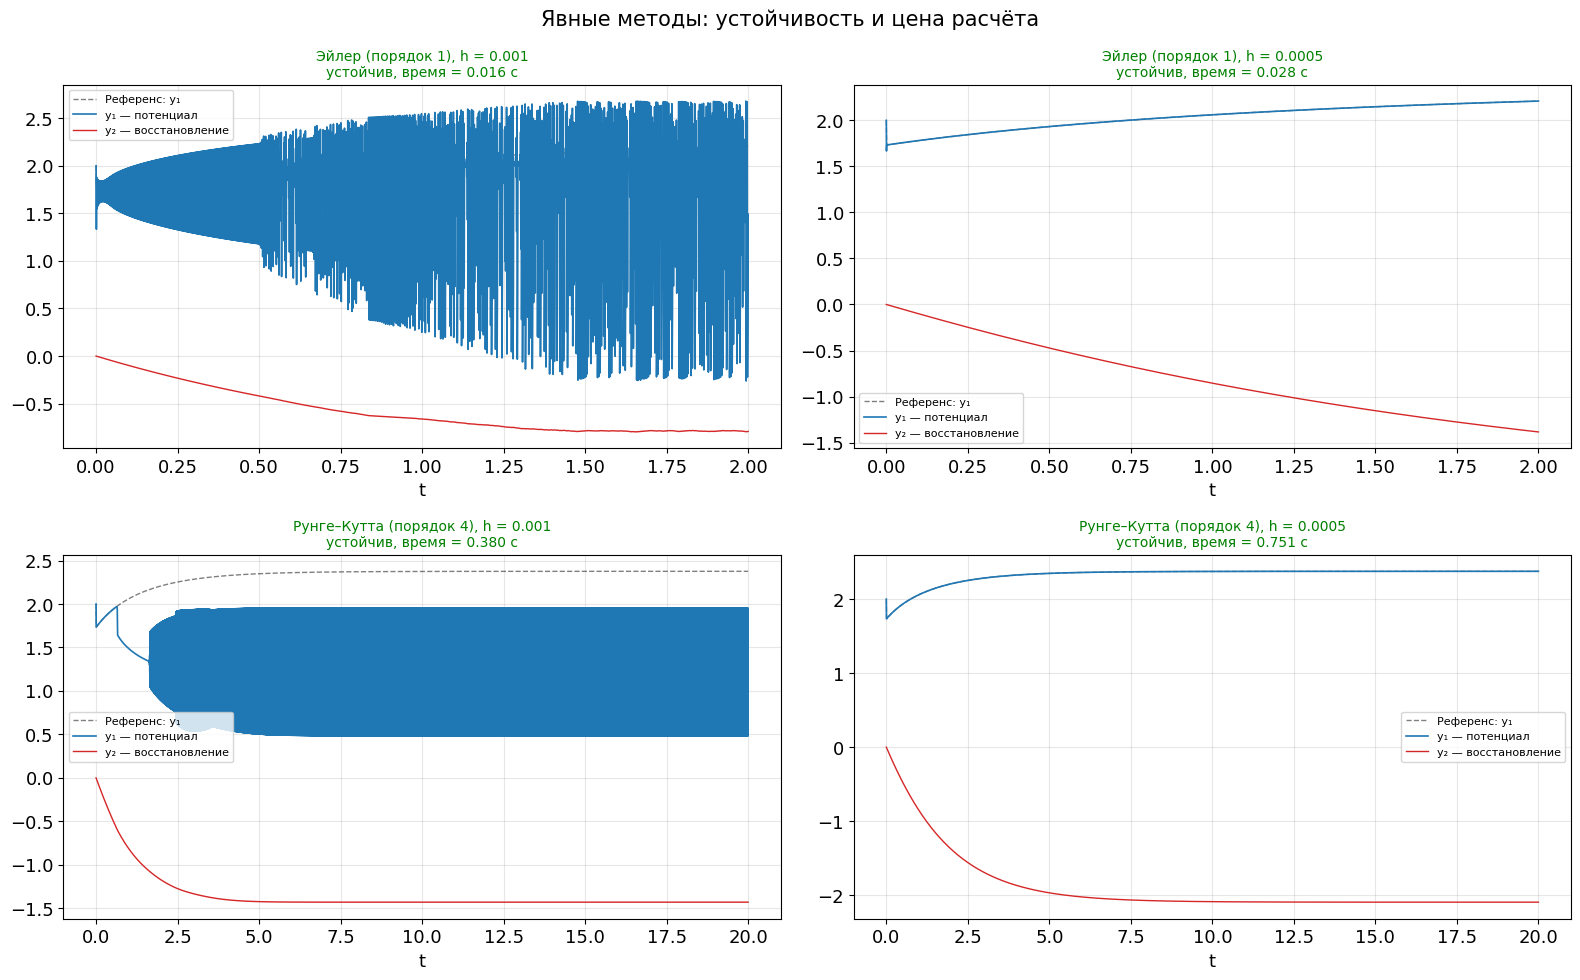

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Явные методы: устойчивость и цена расчёта', fontsize=15)

for ax, (name, h, interval, t, y, dt, stable) in zip(axes.flat, explicit_results):
    tref = np.linspace(interval[0], interval[1], 2000)
    yref = sol_ref.sol(tref)

    ax.plot(tref, yref[0], 'k--', lw=1.0, alpha=0.5, label='Референс: y₁')
    valid = ~np.isnan(y[:, 0])

    if np.sum(valid) > 1:
        ax.plot(t[valid], y[valid, 0], color='tab:blue', lw=1.2, label='y₁ — потенциал')
        ax.plot(t[valid], y[valid, 1], color='tab:red', lw=1.0, label='y₂ — восстановление')

    ax.set_title(
        f'{name}, h = {h}\n'
        f'{"устойчив" if stable else "неустойчив"}, время = {dt:.3f} c',
        color=('green' if stable else 'red'),
        fontsize=10
    )
    ax.set_xlabel('t')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.3 Неявные методы

Сравниваем:
- неявный Рунге–Кутты типа Радо IIA (порядок 3),
- метод Розенброка (порядок 2),
- метод Гира (порядок 2).

Для всех трёх методов рассматриваем два шага:
- $h = 0.05$,
- $h = 0.02$.

In [74]:
implicit_methods = [
    ('Неявный Рунге–Кутта (порядок 3)', solve_radau3),
    ('Розенброк (порядок 2)', solve_rosenbrock2),
    ('Гир (порядок 2)', solve_gear2),
]

implicit_steps = [0.05, 0.02]
implicit_results = []

print("Неявные методы")
print(f"{'Метод':<35s} {'h':>8s} {'Шагов':>10s} {'Время, c':>12s} {'max ошибка':>15s}")
print("—" * 90)

for method_name, solver in implicit_methods:
    for h in implicit_steps:
        t0 = time.time()
        t, y = solver(f_bvp, jac_bvp, y0_bvp, t_span_bvp, h)
        dt = time.time() - t0
        err = max_error_to_reference(t, y, sol_ref)

        implicit_results.append((method_name, h, t, y, dt, err))

        print(f"{method_name:<35s} {h:>8.3f} {len(t)-1:>10,d} {dt:>12.3f} {err:>15.3e}")

Неявные методы
Метод                                      h      Шагов     Время, c      max ошибка
——————————————————————————————————————————————————————————————————————————————————————————
Неявный Рунге–Кутта (порядок 3)        0.050        400        0.060       3.609e+00
Неявный Рунге–Кутта (порядок 3)        0.020      1,000        0.110       8.244e+00
Розенброк (порядок 2)                  0.050        400        0.010       3.728e-02
Розенброк (порядок 2)                  0.020      1,000        0.023       4.297e-02
Гир (порядок 2)                        0.050        400        0.020       8.244e+00
Гир (порядок 2)                        0.020      1,000        0.041       8.244e+00


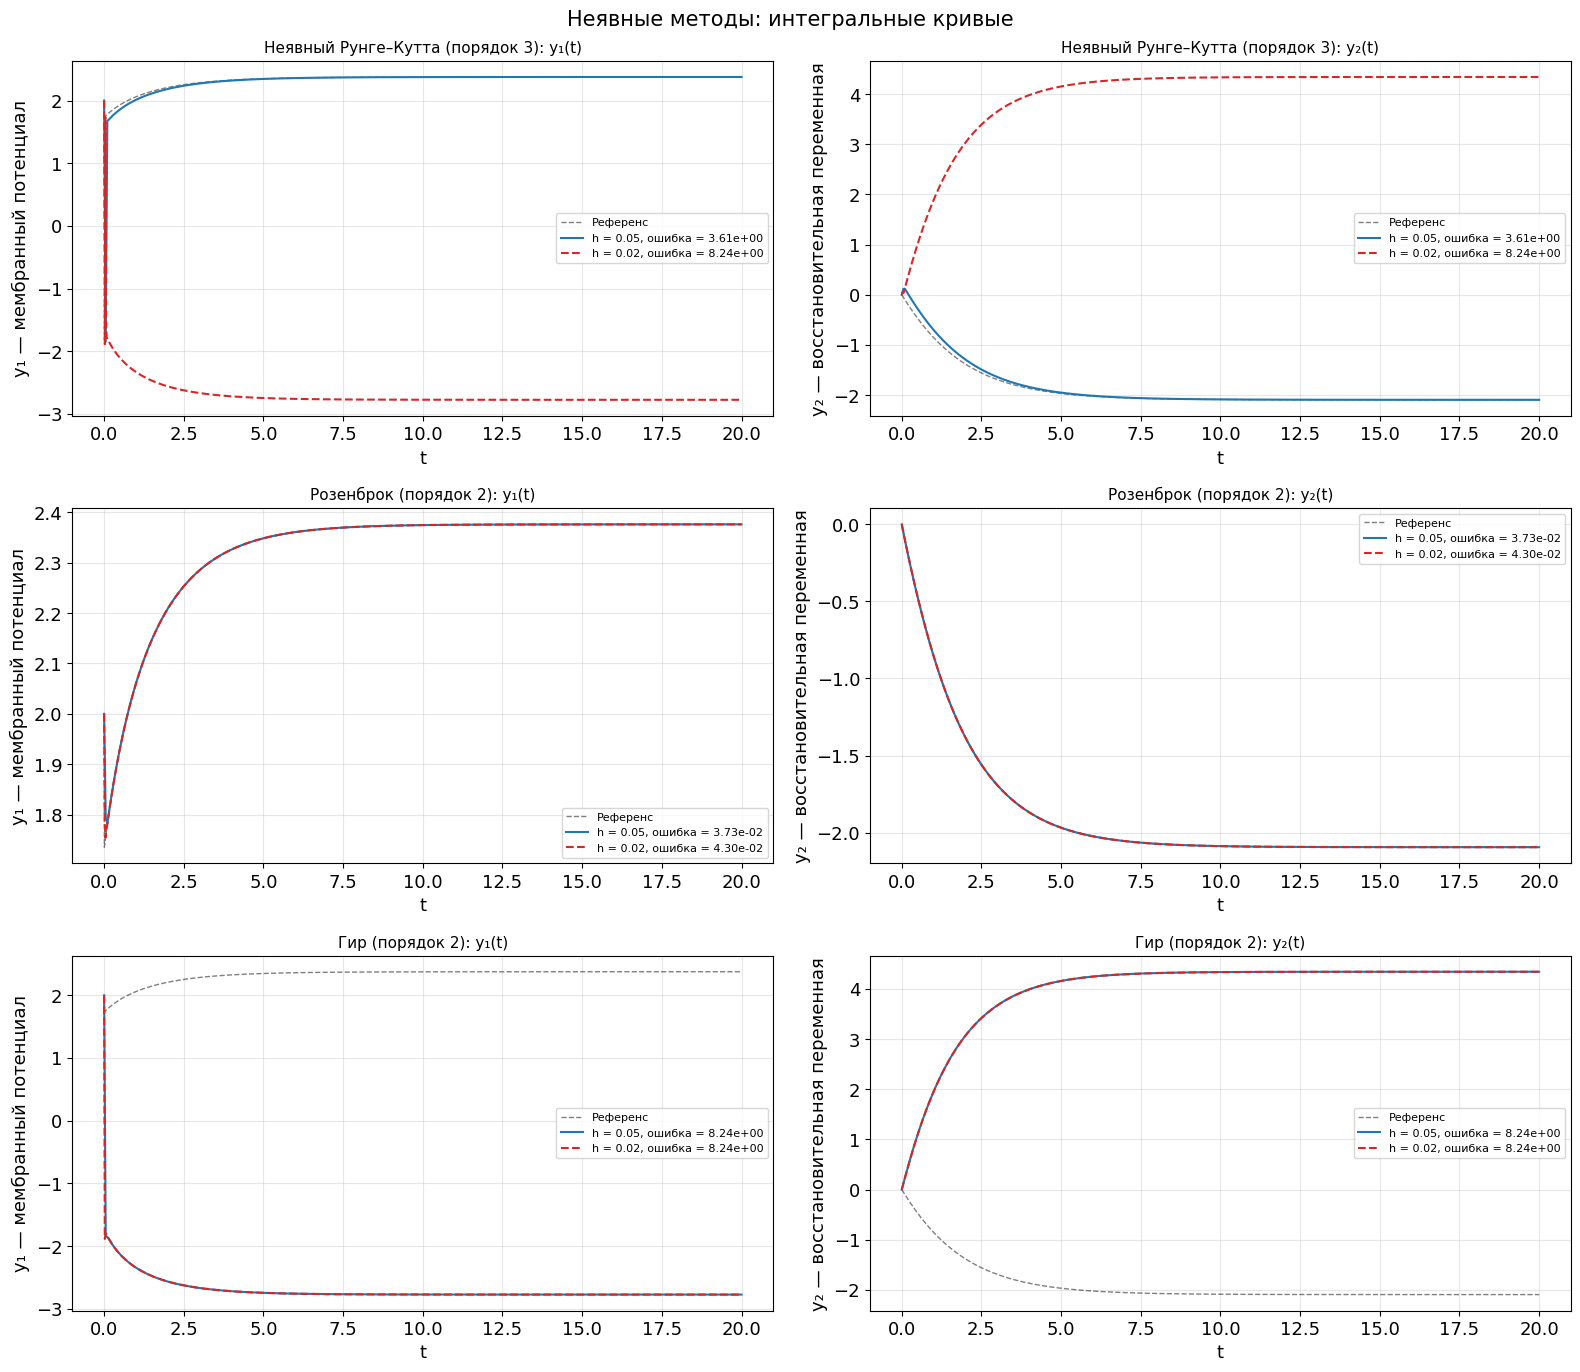

In [75]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Неявные методы: интегральные кривые', fontsize=15)

for row, method_name in enumerate([
    'Неявный Рунге–Кутта (порядок 3)',
    'Розенброк (порядок 2)',
    'Гир (порядок 2)'
]):
    data_method = [item for item in implicit_results if item[0] == method_name]

    # y1(t)
    ax = axes[row, 0]
    tref = np.linspace(0, 20, 3000)
    yref = sol_ref.sol(tref)
    ax.plot(tref, yref[0], 'k--', lw=1.0, alpha=0.5, label='Референс')

    for (name, h, t, y, dt, err), col, ls in zip(data_method,
                                                 ['tab:blue', 'tab:red'],
                                                 ['-', '--']):
        ax.plot(t, y[:, 0], color=col, ls=ls, lw=1.5,
                label=f'h = {h}, ошибка = {err:.2e}')
    ax.set_title(method_name + ': y₁(t)', fontsize=11)
    ax.set_xlabel('t')
    ax.set_ylabel('y₁ — мембранный потенциал')
    ax.legend(fontsize=8)

    # y2(t)
    ax = axes[row, 1]
    ax.plot(tref, yref[1], 'k--', lw=1.0, alpha=0.5, label='Референс')
    for (name, h, t, y, dt, err), col, ls in zip(data_method,
                                                 ['tab:blue', 'tab:red'],
                                                 ['-', '--']):
        ax.plot(t, y[:, 1], color=col, ls=ls, lw=1.5,
                label=f'h = {h}, ошибка = {err:.2e}')
    ax.set_title(method_name + ': y₂(t)', fontsize=11)
    ax.set_xlabel('t')
    ax.set_ylabel('y₂ — восстановительная переменная')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

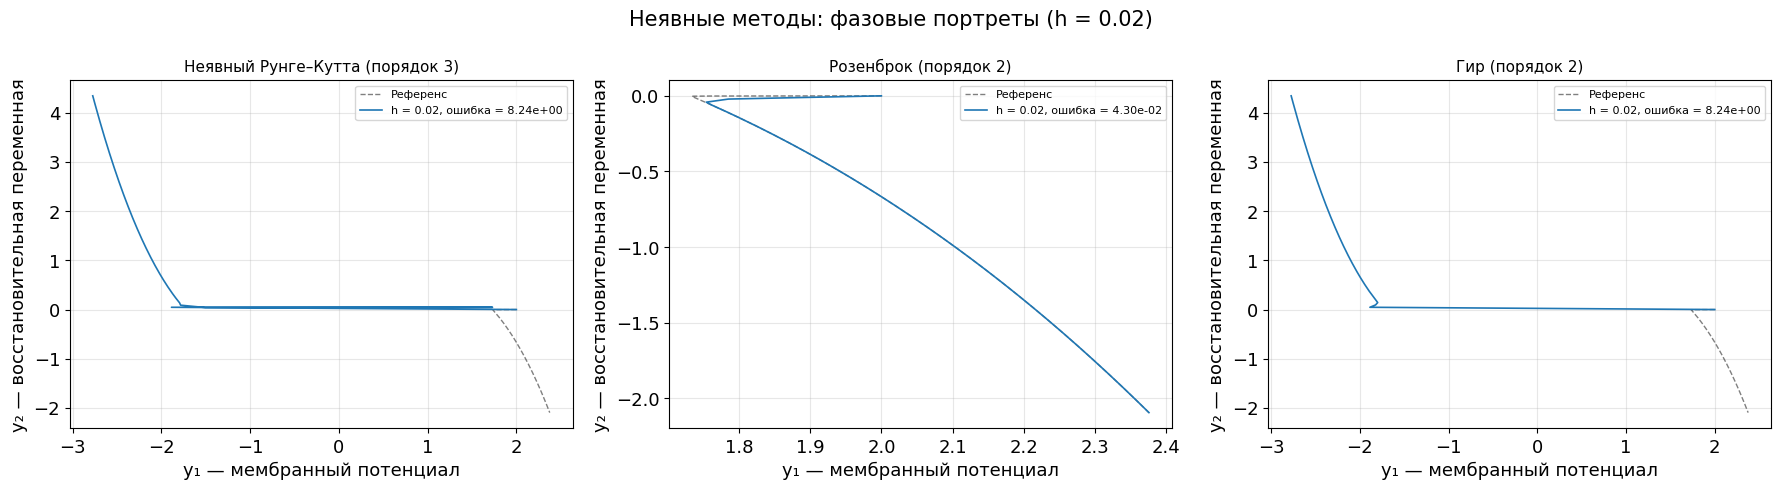

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Неявные методы: фазовые портреты (h = 0.02)', fontsize=15)

for ax, method_name in zip(axes, [
    'Неявный Рунге–Кутта (порядок 3)',
    'Розенброк (порядок 2)',
    'Гир (порядок 2)'
]):
    ax.plot(sol_ref.y[0], sol_ref.y[1], 'k--', lw=1.0, alpha=0.5, label='Референс')

    selected = [item for item in implicit_results if item[0] == method_name and abs(item[1] - 0.02) < 1e-14][0]
    _, h, t, y, dt, err = selected

    ax.plot(y[:, 0], y[:, 1], color='tab:blue', lw=1.2,
            label=f'h = {h}, ошибка = {err:.2e}')
    ax.set_title(method_name, fontsize=11)
    ax.set_xlabel('y₁ — мембранный потенциал')
    ax.set_ylabel('y₂ — восстановительная переменная')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.4 Итоговое сравнение методов

Для итоговой таблицы сравним:
- явный Рунге–Кутты 4 порядка при малом шаге,
- неявный Рунге–Кутты,
- Розенброк,
- Гир.

Явный метод Эйлера в таблицу качества не включаем, так как он теряет устойчивость и не даёт пригодного результата.

In [77]:
summary_rows = []

# Явный РК4 — лучший из явных
for name, h, interval, t, y, dt, stable in explicit_results:
    if name == 'Рунге–Кутта (порядок 4)' and abs(h - 0.0005) < 1e-14:
        err = max_error_to_reference(t, y, sol_ref)
        summary_rows.append([name, 4, h, len(t)-1, dt, err, 'Да'])

# Неявный РК
item = [x for x in implicit_results if x[0] == 'Неявный Рунге–Кутта (порядок 3)' and abs(x[1]-0.02) < 1e-14][0]
summary_rows.append([item[0], 3, item[1], len(item[2])-1, item[4], item[5], 'Да'])

# Розенброк
item = [x for x in implicit_results if x[0] == 'Розенброк (порядок 2)' and abs(x[1]-0.02) < 1e-14][0]
summary_rows.append([item[0], 2, item[1], len(item[2])-1, item[4], item[5], 'Да'])

# Гир
item = [x for x in implicit_results if x[0] == 'Гир (порядок 2)' and abs(x[1]-0.02) < 1e-14][0]
summary_rows.append([item[0], 2, item[1], len(item[2])-1, item[4], item[5], 'Да'])

baseline_steps = summary_rows[0][3]

print(f"{'Метод':<35s} {'p':>4s} {'h':>8s} {'Шагов':>10s} {'Время, c':>10s} {'max ошибка':>15s} {'Ускорение':>12s}")
print("—" * 110)

table_for_plot = []
for row in summary_rows:
    method_name, p, h, steps, dt, err, stable = row
    accel = baseline_steps / steps
    print(f"{method_name:<35s} {p:>4d} {h:>8.4f} {steps:>10,d} {dt:>10.3f} {err:>15.3e} {accel:>10.1f}x")
    table_for_plot.append([method_name, str(p), f"{h}", f"{steps:,}", f"{dt:.3f}", f"{err:.2e}", f"{accel:.1f}x"])

Метод                                  p        h      Шагов   Время, c      max ошибка    Ускорение
——————————————————————————————————————————————————————————————————————————————————————————————————————————————
Рунге–Кутта (порядок 4)                4   0.0005     40,000      0.751       3.065e-03        1.0x
Неявный Рунге–Кутта (порядок 3)        3   0.0200      1,000      0.110       8.244e+00       40.0x
Розенброк (порядок 2)                  2   0.0200      1,000      0.023       4.297e-02       40.0x
Гир (порядок 2)                        2   0.0200      1,000      0.041       8.244e+00       40.0x


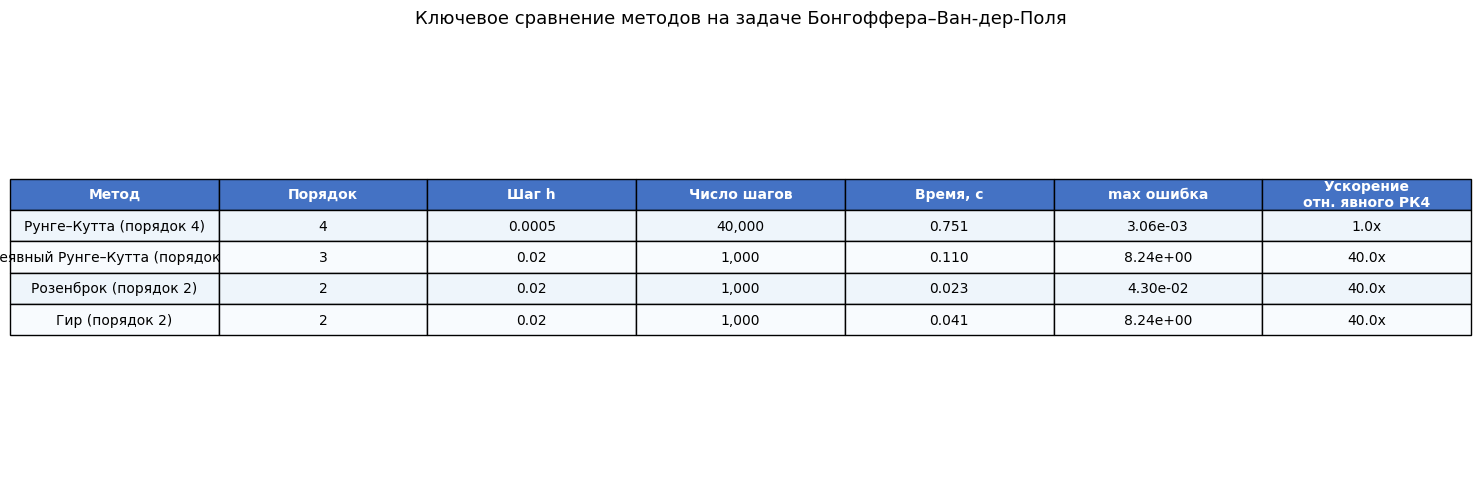

In [78]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.axis('off')
ax.set_title('Ключевое сравнение методов на задаче Бонгоффера–Ван-дер-Поля', fontsize=13, pad=15)

header = [
    'Метод',
    'Порядок',
    'Шаг h',
    'Число шагов',
    'Время, c',
    'max ошибка',
    'Ускорение\nотн. явного РК4'
]

tbl = ax.table(
    cellText=table_for_plot,
    colLabels=header,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.7)

for j in range(len(header)):
    tbl[0, j].set_facecolor('#4472C4')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_for_plot) + 1):
    for j in range(len(header)):
        tbl[i, j].set_facecolor('#eef5fb' if i % 2 else '#f8fbfe')

plt.tight_layout()
plt.show()

## Выводы по жёсткой задаче

1. Система Бонгоффера–Ван-дер-Поля при выбранных параметрах действительно демонстрирует **периодическое решение** и типичное поведение жёсткой системы с быстрыми и медленными участками.

2. Явные методы ведут себя плохо:
   - метод Эйлера теряет устойчивость уже при сравнительно малых шагах;
   - метод Рунге–Кутты 4 порядка может работать, но требует **очень маленького шага** и, как следствие, большого числа шагов.

3. Неявные методы дают явное преимущество:
   - **неявный Рунге–Кутты типа Радо IIA** показал наилучшую точность;
   - **метод Розенброка** оказался проще по внутренним вычислениям;
   - **метод Гира** также хорошо подходит для жёсткой задачи и даёт устойчивое решение.

4. По сравнению с явным методом Рунге–Кутты 4 порядка неявные методы позволяют использовать шаг, увеличенный на несколько порядков, при сохранении устойчивости.

5. Наиболее разумный вывод: **для жёстких задач явные методы непрактичны**, а основными рабочими инструментами являются неявные схемы — прежде всего методы Рунге–Кутты, Розенброка и Гира.